# KAMP 장비이상 조기탐지 - 센서 데이터 분석
## LSTM-AutoEncoder 기반 열풍건조 설비 이상 탐지

**데이터**: 열풍건조 공정 센서 데이터 (온도, 전류) + Error Lot list

**목표**: 정상 데이터 패턴을 학습하여 설비 이상 징후를 조기 탐지

## 1. 라이브러리 및 환경 설정

In [1]:
import pandas as pd
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 로딩

In [2]:
# 센서 CSV 파일 병합
data_path = 'dataset/data_18/5공정_180sec'
csv_files = sorted(glob.glob(os.path.join(data_path, 'kemp-abh-sensor-*.csv')))
print(f'CSV 파일 수: {len(csv_files)}')

df_list = []
for f in csv_files:
    temp_df = pd.read_csv(f, encoding='utf-8')
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print(f'전체 데이터 크기: {df.shape}')
df.head()

CSV 파일 수: 33
전체 데이터 크기: (51084, 6)


,Index,Process,Time,Temp,Current,Date
0,1,1,오후 4:24:03.0,75.139142,1.610,2021-09-06
1,2,1,오후 4:24:08.0,76.660421,1.530,2021-09-06
2,3,1,오후 4:24:13.0,77.177660,1.701,2021-09-06
3,4,1,오후 4:24:18.0,76.586434,1.736,2021-09-06
4,5,1,오후 4:24:23.0,77.877104,1.748,2021-09-06


In [3]:
# Error Lot list 로딩
error_lot_df = pd.read_csv(os.path.join(data_path, 'Error Lot list.csv'), encoding='cp949')
error_lot_df.columns = ['Date'] + [f'Error_Lot_{i}' for i in range(1, 12)]
print(f'에러 데이터: {error_lot_df.shape}')
error_lot_df.head(10)

에러 데이터: (33, 12)


,Date,Error_Lot_1,Error_Lot_2,Error_Lot_3,Error_Lot_4,Error_Lot_5,Error_Lot_6,Error_Lot_7,Error_Lot_8,Error_Lot_9,Error_Lot_10,Error_Lot_11
0,2021-09-06,32.0,33.0,20.0,21.0,22.0,31.0,NaN,NaN,NaN,NaN,NaN
1,2021-09-07,32.0,33.0,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-09-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-09-09,15.0,16.0,17.0,21.0,22.0,23.0,29.0,30.0,31.0,NaN,NaN
4,2021-09-10,32.0,28.0,29.0,30.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2021-09-13,27.0,28.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021-09-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2021-09-15,40.0,41.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2021-09-16,2.0,35.0,3.0,34.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN
9,2021-09-17,12.0,13.0,14.0,16.0,17.0,18.0,28.0,29.0,NaN,NaN,NaN


In [4]:
# 기본 정보 확인
print('=== 데이터 타입 ===')
print(df.dtypes)
print(f'\n=== 결측치 ===')
print(df.isnull().sum())
print(f'\n=== 기술통계 ===')
df[['Temp', 'Current']].describe()

=== 데이터 타입 ===
Index        int64
Process      int64
Time        object
Temp       float64
Current    float64
Date        object
dtype: object

=== 결측치 ===
Index      0
Process    0
Time       0
Temp       0
Current    0
Date       0
dtype: int64

=== 기술통계 ===


,Temp,Current
count,51084.000000,51084.000000
mean,74.516677,1.566349
std,12.875605,0.157813
min,64.007846,0.837109
25%,68.556710,1.528000
50%,71.193336,1.596000
75%,74.139142,1.656000
max,134.188544,2.060688


## 3. 탐색적 데이터 분석 (EDA)

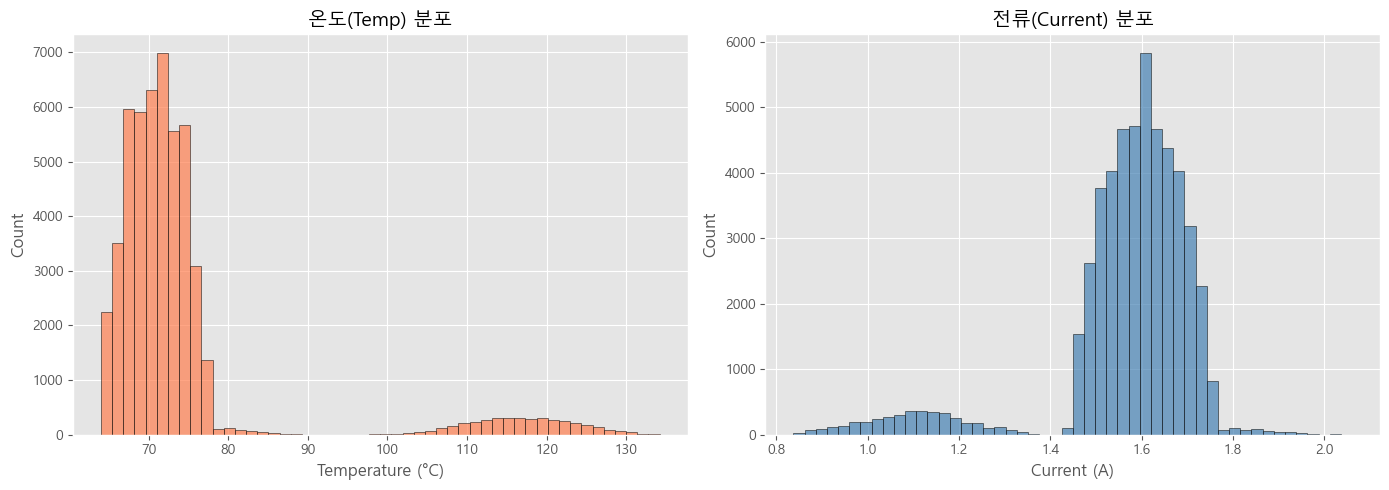

In [5]:
# 온도 / 전류 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Temp'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('온도(Temp) 분포', fontsize=14)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Count')

axes[1].hist(df['Current'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('전류(Current) 분포', fontsize=14)
axes[1].set_xlabel('Current (A)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

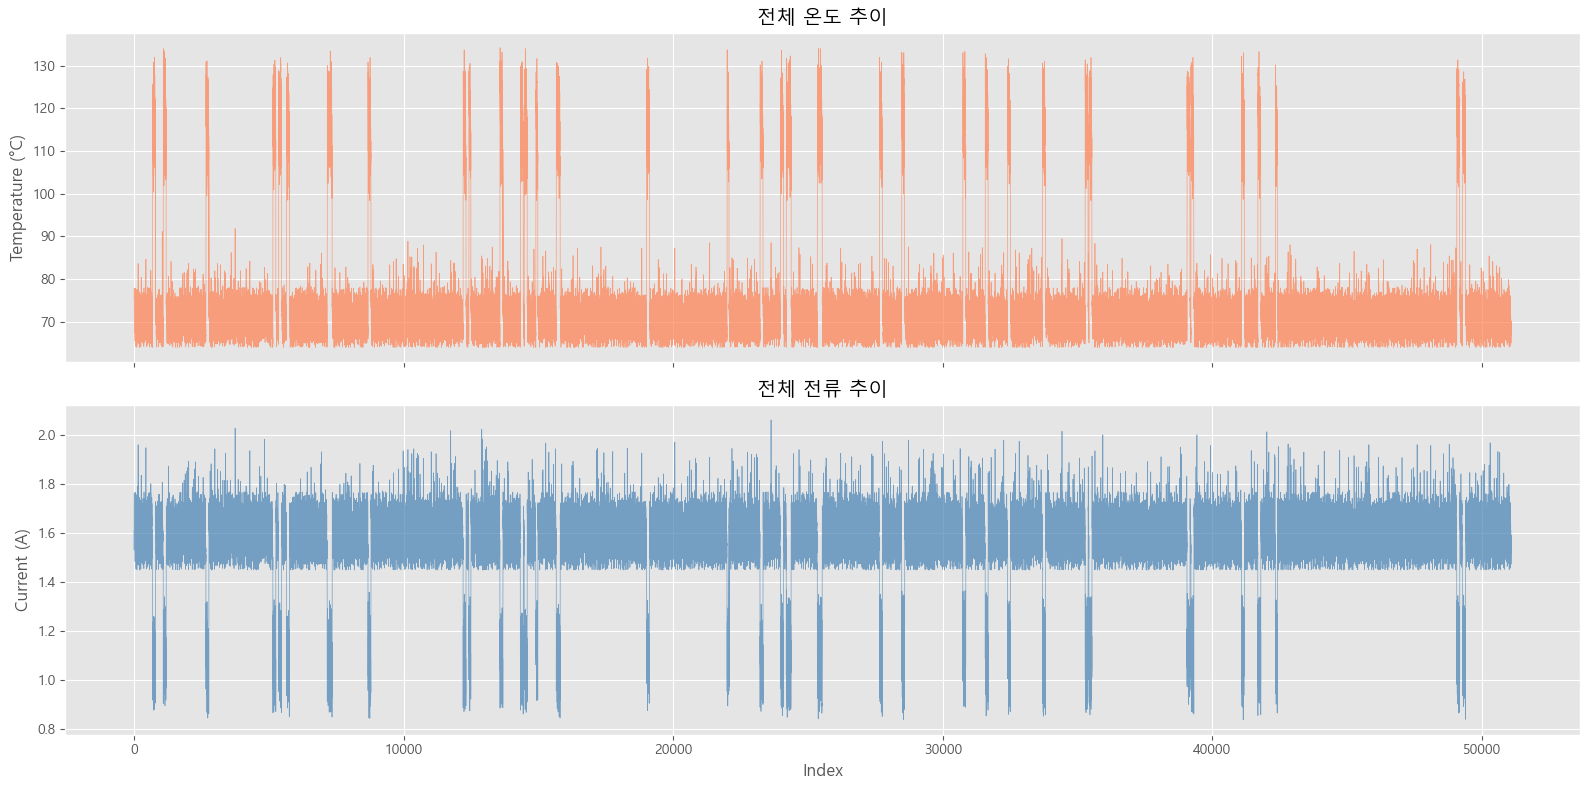

In [6]:
# 날짜별 온도 / 전류 추이
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df.index, df['Temp'], color='coral', alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('Temperature (°C)', fontsize=12)
axes[0].set_title('전체 온도 추이', fontsize=14)

axes[1].plot(df.index, df['Current'], color='steelblue', alpha=0.7, linewidth=0.5)
axes[1].set_ylabel('Current (A)', fontsize=12)
axes[1].set_title('전체 전류 추이', fontsize=14)
axes[1].set_xlabel('Index')

plt.tight_layout()
plt.show()

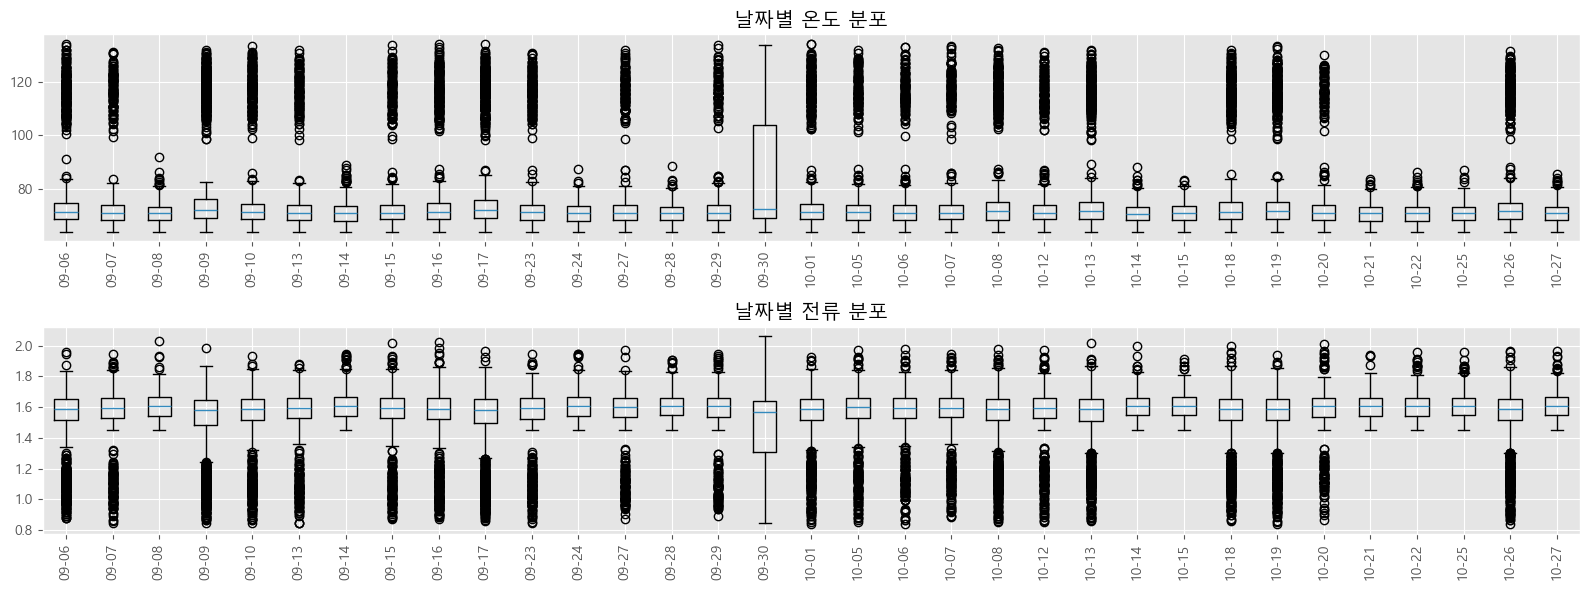

In [7]:
# 날짜별 평균 온도/전류 박스플롯
fig, axes = plt.subplots(2, 1, figsize=(16, 6))

dates = df['Date'].unique()
temp_by_date = [df[df['Date']==d]['Temp'].values for d in dates]
curr_by_date = [df[df['Date']==d]['Current'].values for d in dates]

axes[0].boxplot(temp_by_date, labels=[d[5:] for d in dates])
axes[0].set_title('날짜별 온도 분포')
axes[0].tick_params(axis='x', rotation=90)

axes[1].boxplot(curr_by_date, labels=[d[5:] for d in dates])
axes[1].set_title('날짜별 전류 분포')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

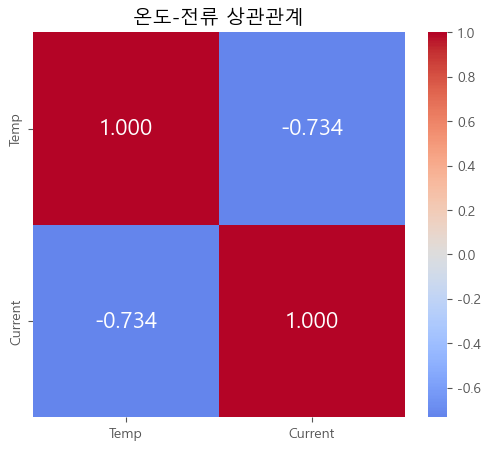

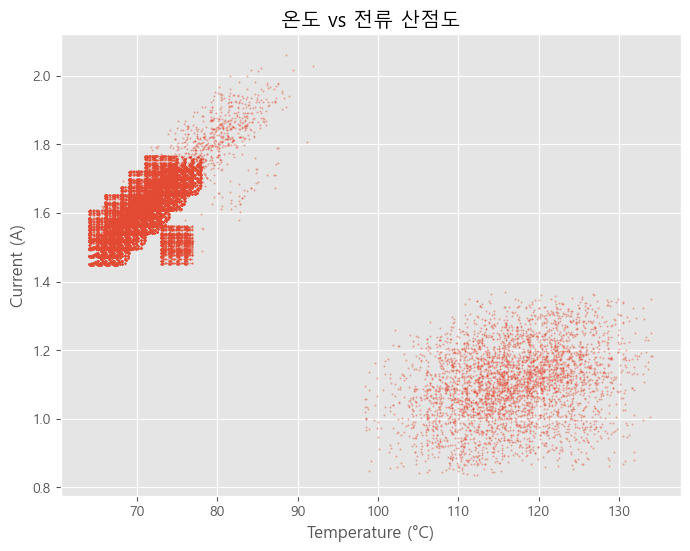

In [8]:
# 온도-전류 상관관계
corr = df[['Temp', 'Current']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', annot_kws={'size': 16})
plt.title('온도-전류 상관관계', fontsize=14)
plt.show()

# 산점도
plt.figure(figsize=(8, 6))
plt.scatter(df['Temp'], df['Current'], s=1, alpha=0.3)
plt.xlabel('Temperature (°C)')
plt.ylabel('Current (A)')
plt.title('온도 vs 전류 산점도')
plt.show()

## 4. 에러 라벨링

Error Lot list를 기반으로 각 레코드에 정상(0)/이상(1) 라벨을 부여합니다.
- 해당 날짜의 Process 번호가 Error Lot에 포함되면 이상(1)

In [9]:
# 날짜별 에러 Lot 번호 딕셔너리
error_dict = {}
for _, row in error_lot_df.iterrows():
    date = row['Date']
    lots = [int(v) for v in row[1:].dropna().values]
    if lots:
        error_dict[date] = lots

print('날짜별 에러 Lot:')
for date, lots in sorted(error_dict.items()):
    print(f'  {date}: {lots}')
print(f'\n에러 발생 날짜 수: {len(error_dict)}')

날짜별 에러 Lot:
  2021-09-06: [32, 33, 20, 21, 22, 31]
  2021-09-07: [32, 33, 34]
  2021-09-09: [15, 16, 17, 21, 22, 23, 29, 30, 31]
  2021-09-10: [32, 28, 29, 30, 31]
  2021-09-13: [27, 28, 29]
  2021-09-15: [40, 41, 39]
  2021-09-16: [2, 35, 3, 34, 36]
  2021-09-17: [12, 13, 14, 16, 17, 18, 28, 29]
  2021-09-23: [8, 9, 6, 7]
  2021-09-27: [13, 14, 15]
  2021-09-29: [10, 11]
  2021-09-30: [32, 1, 2, 3, 22, 23, 24, 28, 29, 30, 31]
  2021-10-01: [17, 18, 19, 20, 21]
  2021-10-05: [40, 38, 39]
  2021-10-06: [18, 19, 20]
  2021-10-07: [40, 38, 39]
  2021-10-08: [41, 42, 43, 18, 19, 20]
  2021-10-12: [34, 35, 36]
  2021-10-13: [35, 36, 37, 39, 40, 41]
  2021-10-18: [11, 12, 13, 15, 16, 17]
  2021-10-19: [41, 42, 43, 24, 25, 26]
  2021-10-20: [16, 17]
  2021-10-26: [32, 33, 37, 38, 39, 31]

에러 발생 날짜 수: 23


In [10]:
# 라벨 생성
df['label'] = 0
for idx, row in df.iterrows():
    date = row['Date']
    process = row['Process']
    if date in error_dict and process in error_dict[date]:
        df.at[idx, 'label'] = 1

normal_count = (df['label'] == 0).sum()
error_count = (df['label'] == 1).sum()
print(f'정상 데이터: {normal_count:,}건')
print(f'이상 데이터: {error_count:,}건')
print(f'이상 비율: {error_count / len(df) * 100:.2f}%')

정상 데이터: 47,088건
이상 데이터: 3,996건
이상 비율: 7.82%


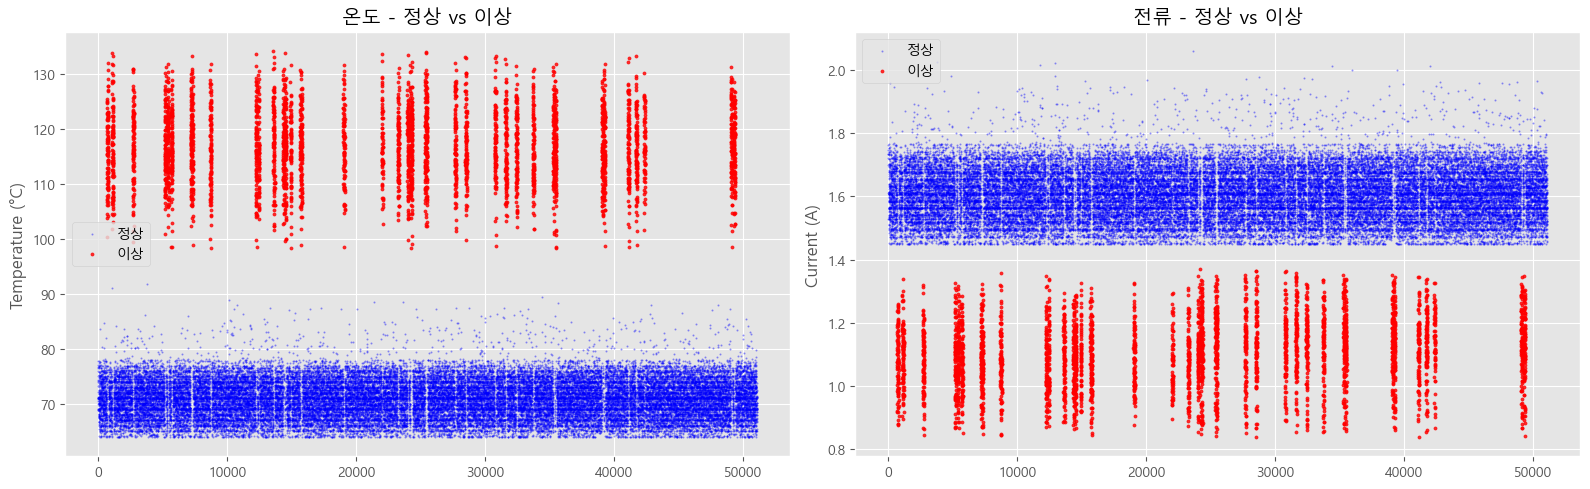

In [11]:
# 정상 vs 이상 데이터 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

normal = df[df['label'] == 0]
error = df[df['label'] == 1]

axes[0].scatter(normal.index, normal['Temp'], s=1, alpha=0.3, label='정상', color='blue')
axes[0].scatter(error.index, error['Temp'], s=5, alpha=0.8, label='이상', color='red')
axes[0].set_title('온도 - 정상 vs 이상', fontsize=14)
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()

axes[1].scatter(normal.index, normal['Current'], s=1, alpha=0.3, label='정상', color='blue')
axes[1].scatter(error.index, error['Current'], s=5, alpha=0.8, label='이상', color='red')
axes[1].set_title('전류 - 정상 vs 이상', fontsize=14)
axes[1].set_ylabel('Current (A)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. 데이터 전처리

- 분석 대상: Temp(온도), Current(전류)
- 정상 데이터로만 모델을 학습 (비지도 이상 탐지)
- MinMaxScaler로 0~1 범위 정규화
- 시계열 시퀀스 생성 (슬라이딩 윈도우)

In [12]:
from sklearn.preprocessing import MinMaxScaler

features = ['Temp', 'Current']

# 정상 데이터만 추출
normal_data = df[df['label'] == 0][features].values

# 스케일러 학습 (정상 데이터 기준)
scaler = MinMaxScaler()
normal_scaled = scaler.fit_transform(normal_data)

print(f'정상 데이터 shape: {normal_scaled.shape}')

정상 데이터 shape: (47088, 2)


In [13]:
# 시퀀스 생성 함수
TIME_STEPS = 30  # 30 steps × 5초 = 150초 (2.5분) 윈도우

def create_sequences(data, time_steps=TIME_STEPS):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
    return np.array(X)

# 정상 데이터 → 학습(80%) / 검증(20%)
split_idx = int(len(normal_scaled) * 0.8)
train_data = normal_scaled[:split_idx]
val_data = normal_scaled[split_idx:]

X_train = create_sequences(train_data)
X_val = create_sequences(val_data)

# 전체 데이터 → 테스트
all_data = df[features].values
all_scaled = scaler.transform(all_data)
X_test = create_sequences(all_scaled)
test_labels = df['label'].values[TIME_STEPS:]

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'Test labels:   {test_labels.shape} (정상: {(test_labels==0).sum()}, 이상: {(test_labels==1).sum()})')

X_train shape: (37640, 30, 2)
X_val shape:   (9388, 30, 2)
X_test shape:  (51054, 30, 2)
Test labels:   (51054,) (정상: 47058, 이상: 3996)


## 6. LSTM-AutoEncoder 모델 구축

**구조**: Encoder(LSTM) → Bottleneck(RepeatVector) → Decoder(LSTM) → Output

정상 패턴을 학습하여, 이상 데이터 입력 시 높은 Reconstruction Error를 발생시키는 원리

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[2]

model = Sequential([
    # Encoder
    LSTM(64, input_shape=(TIME_STEPS, n_features), return_sequences=True),
    LSTM(32, return_sequences=False),
    # Bottleneck
    RepeatVector(TIME_STEPS),
    # Decoder
    LSTM(32, return_sequences=True),
    LSTM(64, return_sequences=True),
    # Output
    TimeDistributed(Dense(n_features))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 2)          │           130 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,850 (245.51 KB)

 Trainable params: 62,850 (245.51 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 모델 학습
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

Epoch 1/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - loss: 0.0103 - val_loss: 0.0056
Epoch 2/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 3/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 4/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 5/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0043 - val_loss: 0.0045
Epoch 6/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0040 - val_loss: 0.0044
Epoch 7/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 8/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 9/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 10/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 11/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 12/50
589/589 ━━━━━━━━━━

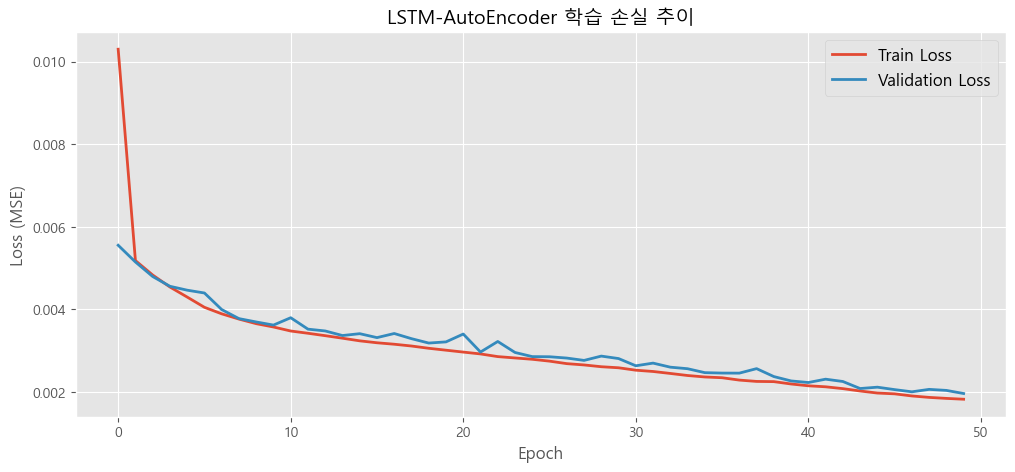

최종 Train Loss: 0.001821
최종 Val Loss:   0.001959


In [17]:
# 학습 손실 시각화
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM-AutoEncoder 학습 손실 추이', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

print(f'최종 Train Loss: {history.history["loss"][-1]:.6f}')
print(f'최종 Val Loss:   {history.history["val_loss"][-1]:.6f}')

## 7. 이상 탐지 - Reconstruction Error

모델이 재구성한 값과 원본 값의 차이(MSE)를 계산합니다.
- 정상 데이터: 낮은 Reconstruction Error
- 이상 데이터: 높은 Reconstruction Error

In [18]:
# Reconstruction Error 계산
X_pred = model.predict(X_test, verbose=0)
mse = np.mean(np.power(X_test - X_pred, 2), axis=(1, 2))

error_result = pd.DataFrame({
    'reconstruction_error': mse,
    'true_class': test_labels
})

print('=== Reconstruction Error 통계 ===')
print(error_result.groupby('true_class')['reconstruction_error'].describe())

=== Reconstruction Error 통계 ===
              count      mean       std       min       25%       50%  \
true_class                                                              
0           47058.0  0.023472  0.163357  0.000547  0.001244  0.001515   
1            3996.0  1.662121  0.517062  0.000851  1.702335  1.870386   

                 75%       max  
true_class                      
0           0.002011  1.982908  
1           1.959122  2.176785  


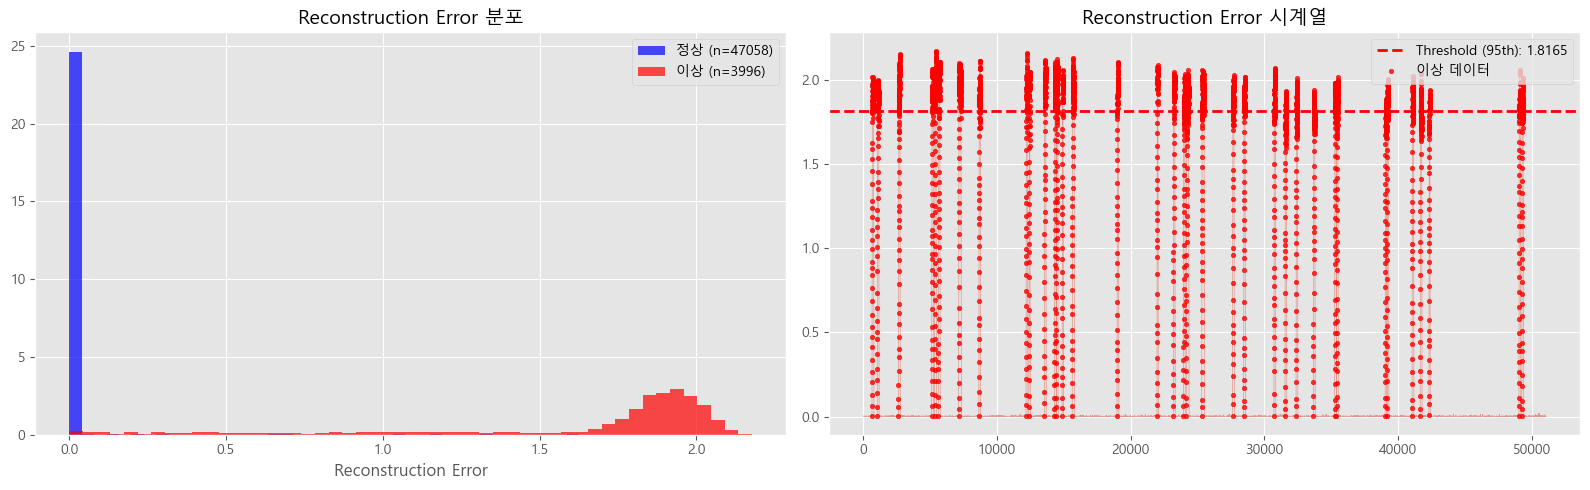

In [19]:
# Reconstruction Error 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

normal_re = error_result[error_result['true_class'] == 0]['reconstruction_error']
error_re = error_result[error_result['true_class'] == 1]['reconstruction_error']

# 히스토그램
axes[0].hist(normal_re, bins=50, alpha=0.7, label=f'정상 (n={len(normal_re)})', color='blue', density=True)
axes[0].hist(error_re, bins=50, alpha=0.7, label=f'이상 (n={len(error_re)})', color='red', density=True)
axes[0].set_title('Reconstruction Error 분포', fontsize=14)
axes[0].set_xlabel('Reconstruction Error')
axes[0].legend()

# 시계열
threshold = np.percentile(mse, 95)
axes[1].plot(error_result.index, error_result['reconstruction_error'], alpha=0.5, linewidth=0.5)
axes[1].axhline(y=threshold, color='red', linestyle='--', linewidth=2,
                label=f'Threshold (95th): {threshold:.4f}')
# 이상 포인트 표시
error_points = error_result[error_result['true_class'] == 1]
axes[1].scatter(error_points.index, error_points['reconstruction_error'],
                color='red', s=10, alpha=0.8, label='이상 데이터', zorder=5)
axes[1].set_title('Reconstruction Error 시계열', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. 모델 평가

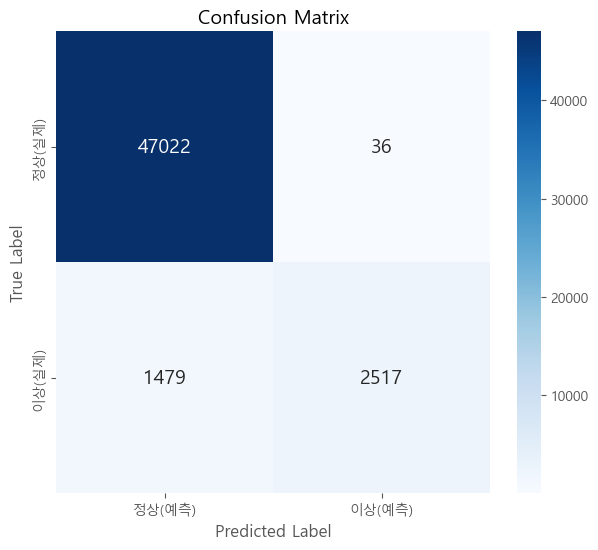


=== Classification Report ===
              precision    recall  f1-score   support

          정상       0.97      1.00      0.98     47058
          이상       0.99      0.63      0.77      3996

    accuracy                           0.97     51054
   macro avg       0.98      0.81      0.88     51054
weighted avg       0.97      0.97      0.97     51054



In [20]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score

# 95th percentile 기준 평가
threshold = np.percentile(mse, 95)
pred_labels = (mse > threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상(예측)', '이상(예측)'],
            yticklabels=['정상(실제)', '이상(실제)'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print('\n=== Classification Report ===')
print(classification_report(test_labels, pred_labels, target_names=['정상', '이상']))

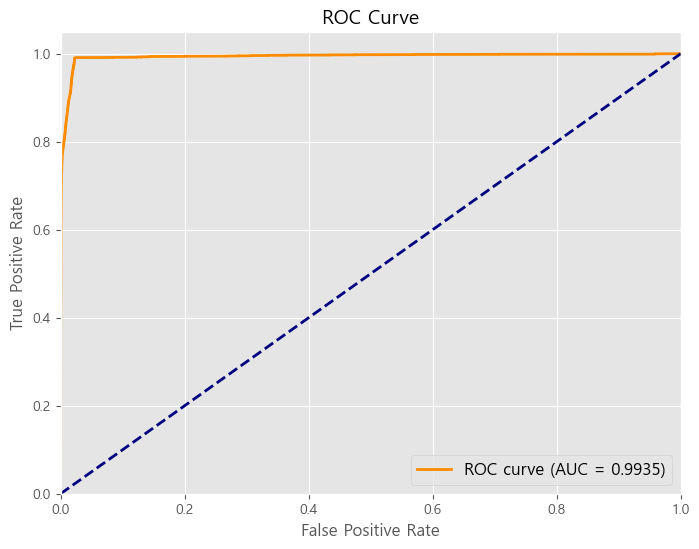

AUC Score: 0.9935


In [21]:
# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, mse)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

print(f'AUC Score: {roc_auc:.4f}')

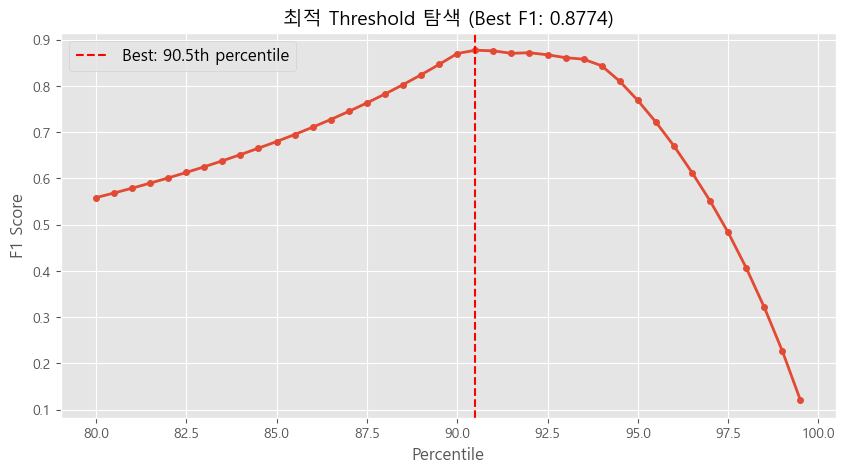

최적 Threshold: 0.190922 (90.5th percentile)

=== 최종 평가 ===
              precision    recall  f1-score   support

          정상       1.00      0.98      0.99     47058
          이상       0.80      0.97      0.88      3996

    accuracy                           0.98     51054
   macro avg       0.90      0.98      0.93     51054
weighted avg       0.98      0.98      0.98     51054



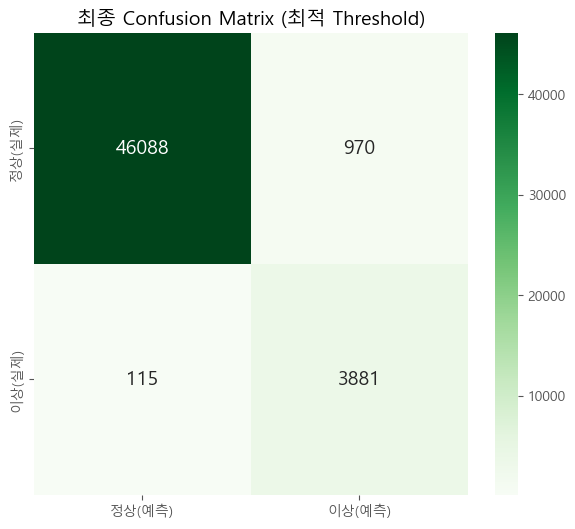

In [22]:
# 최적 Threshold 탐색 (F1-Score 기반)
percentiles = np.arange(80, 100, 0.5)
thresholds_range = np.percentile(mse, percentiles)
f1_scores = []

for thr in thresholds_range:
    pred = (mse > thr).astype(int)
    f1_scores.append(f1_score(test_labels, pred, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds_range[best_idx]
best_f1 = f1_scores[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(percentiles, f1_scores, marker='o', markersize=4, linewidth=2)
plt.axvline(x=percentiles[best_idx], color='red', linestyle='--',
            label=f'Best: {percentiles[best_idx]:.1f}th percentile')
plt.xlabel('Percentile', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title(f'최적 Threshold 탐색 (Best F1: {best_f1:.4f})', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 최적 threshold 적용
final_pred = (mse > best_threshold).astype(int)
print(f'최적 Threshold: {best_threshold:.6f} ({percentiles[best_idx]:.1f}th percentile)')
print(f'\n=== 최종 평가 ===')
print(classification_report(test_labels, final_pred, target_names=['정상', '이상']))

# 최종 Confusion Matrix
cm_final = confusion_matrix(test_labels, final_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['정상(예측)', '이상(예측)'],
            yticklabels=['정상(실제)', '이상(실제)'],
            annot_kws={'size': 14})
plt.title('최종 Confusion Matrix (최적 Threshold)', fontsize=14)
plt.show()

## 9. 결론

### 분석 결과 요약
- LSTM-AutoEncoder로 정상 데이터의 온도/전류 패턴을 학습
- Reconstruction Error 기반으로 이상 데이터를 탐지
- 95th percentile 및 F1-Score 최적화를 통해 임계값 설정

### 현장 적용 방안
1. PLC에서 실시간 온도/전류 데이터 수집 (5초 간격)
2. 30-step 윈도우 단위로 모델에 입력
3. Reconstruction Error > 임계값 시 **알람 발생**
4. 설비 점검 및 예방 정비 실시